In [3]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile

# Update this path to match your actual tea dataset filename in Drive
dataset_zip = '/content/drive/MyDrive/tea_leaf.zip'
extract_path = '/content/Tea_dataset_raw'

with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done")

Mounted at /content/drive
Extraction done


In [10]:
from pathlib import Path
import os

raw_path = Path('/content/Tea_dataset_raw')
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def find_dataset_root(path):
    candidates = []
    for folder in path.rglob("*"):
        if folder.is_dir():
            subdirs = [d for d in folder.iterdir() if d.is_dir()]
            image_count = 0
            for subdir in subdirs:
                image_count += sum(
                    1 for f in subdir.iterdir()
                    if f.is_file() and f.suffix.lower() in image_extensions
                )
            if len(subdirs) >= 2 and image_count > 0:
                candidates.append(folder)
    if not candidates:
        raise ValueError("Could not find dataset root. Check ZIP folder structure.")
    return candidates[0]

dataset_root = find_dataset_root(raw_path)

print("Detected Tea dataset root:", dataset_root)
print("\nClasses and image counts:")
total_images = 0
for class_folder in sorted(os.listdir(dataset_root)):
    class_path = dataset_root / class_folder
    if class_path.is_dir():
        count = sum(1 for f in class_path.iterdir()
                     if f.is_file() and f.suffix.lower() in image_extensions)
        total_images += count
        print(f"- {class_folder}: {count} images")

print(f"\nTotal images: {total_images}")

Detected Tea dataset root: /content/Tea_dataset_raw/tea_leaf

Classes and image counts:
- Anthracnose: 100 images
- algal leaf: 113 images
- bird eye spot: 100 images
- brown blight: 113 images
- gray light: 100 images
- healthy: 74 images
- red leaf spot: 143 images
- white spot: 142 images

Total images: 885


In [11]:
from sklearn.model_selection import train_test_split
import random, shutil

base_dir = '/content/split_dataset_tea'
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(base_dir, split), exist_ok=True)

classes = sorted(os.listdir(dataset_root))

print("Splitting Tea Dataset (70/15/15)\n")

for cls in classes:
    cls_path = dataset_root / cls
    if not cls_path.is_dir():
        continue

    images = [f.name for f in cls_path.iterdir()
              if f.is_file() and f.suffix.lower() in image_extensions]

    random.seed(42)
    random.shuffle(images)

    train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)

    for split, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        split_cls_dir = os.path.join(base_dir, split, cls)
        os.makedirs(split_cls_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(cls_path / img, os.path.join(split_cls_dir, img))

    total = len(images)
    print(f"{cls}: total={total} | train={len(train_imgs)} | val={len(val_imgs)} | test={len(test_imgs)}")

Splitting Tea Dataset (70/15/15)

Anthracnose: total=100 | train=70 | val=15 | test=15
algal leaf: total=113 | train=79 | val=17 | test=17
bird eye spot: total=100 | train=70 | val=15 | test=15
brown blight: total=113 | train=79 | val=17 | test=17
gray light: total=100 | train=70 | val=15 | test=15
healthy: total=74 | train=51 | val=11 | test=12
red leaf spot: total=143 | train=100 | val=21 | test=22
white spot: total=142 | train=99 | val=21 | test=22


In [12]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)
class_names = train_ds.class_names   # capture BEFORE mapping

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(base_dir, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

print("Classes:", class_names)
num_classes = len(class_names)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

def prep_train(image, label):
    image = data_augmentation(image)
    image = preprocess_input(image)
    return image, label

def prep_eval(image, label):
    return preprocess_input(image), label

train_ds = train_ds.map(prep_train, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds = val_ds.map(prep_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(prep_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

Found 618 files belonging to 8 classes.
Found 132 files belonging to 8 classes.
Found 135 files belonging to 8 classes.
Classes: ['Anthracnose', 'algal leaf', 'bird eye spot', 'brown blight', 'gray light', 'healthy', 'red leaf spot', 'white spot']


In [13]:
import numpy as np
from sklearn.utils import class_weight

train_labels = []
for _, labels in train_ds.unbatch():
    train_labels.append(np.argmax(labels.numpy()))

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)

{0: np.float64(1.1035714285714286), 1: np.float64(0.9778481012658228), 2: np.float64(1.1035714285714286), 3: np.float64(0.9778481012658228), 4: np.float64(1.1035714285714286), 5: np.float64(1.5147058823529411), 6: np.float64(0.7725), 7: np.float64(0.7803030303030303)}


In [14]:
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,120 (9.90 MB)

 Trainable params: 333,064 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('/content/drive/MyDrive/tea_best_phase1.keras', monitor='val_accuracy', save_best_only=True)
]

history1 = model.fit(
    train_ds, validation_data=val_ds, epochs=25,
    callbacks=callbacks_phase1, class_weight=class_weights_dict
)

Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.4417 - loss: 2.0400 - val_accuracy: 0.5909 - val_loss: 1.4750 - learning_rate: 0.0010
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7896 - loss: 1.1410 - val_accuracy: 0.6894 - val_loss: 1.2767 - learning_rate: 0.0010
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8689 - loss: 0.9367 - val_accuracy: 0.7045 - val_loss: 1.2134 - learning_rate: 0.0010
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8722 - loss: 0.8955 - val_accuracy: 0.7424 - val_loss: 1.1485 - learning_rate: 0.0010
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9078 - loss: 0.8180 - val_accuracy: 0.7576 - val_loss: 1.1109 - learning_rate: 0.0010
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9401 - loss: 0.7796 - val_accuracy: 0.7576 - val_loss: 1.1079 - learning_rate: 0.0010
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9385 - loss: 0.7624 - val_accuracy: 

In [16]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Tea Model Test Accuracy: {test_acc*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 937ms/step - accuracy: 0.7704 - loss: 1.0641
Tea Model Test Accuracy: 77.04%


Tea Model Test Accuracy: 77.04%


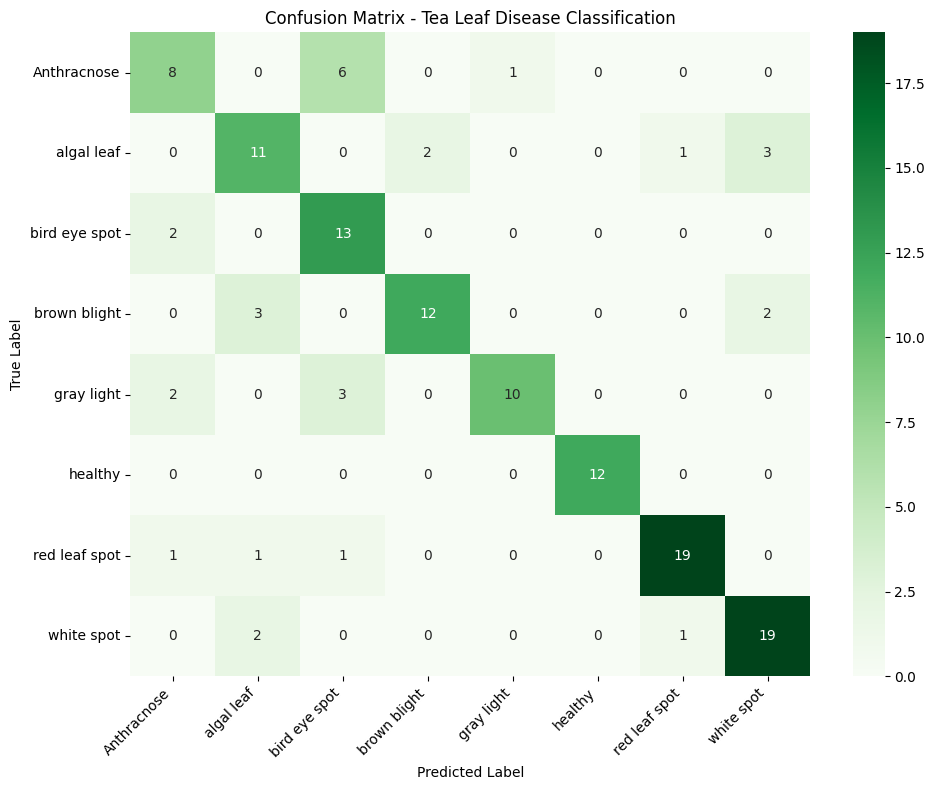

               precision    recall  f1-score   support

  Anthracnose     0.6154    0.5333    0.5714        15
   algal leaf     0.6471    0.6471    0.6471        17
bird eye spot     0.5652    0.8667    0.6842        15
 brown blight     0.8571    0.7059    0.7742        17
   gray light     0.9091    0.6667    0.7692        15
      healthy     1.0000    1.0000    1.0000        12
red leaf spot     0.9048    0.8636    0.8837        22
   white spot     0.7917    0.8636    0.8261        22

     accuracy                         0.7704       135
    macro avg     0.7863    0.7684    0.7695       135
 weighted avg     0.7870    0.7704    0.7715       135



In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Tea Model Test Accuracy: {test_accuracy*100:.2f}%")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tea Leaf Disease Classification')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/tea_confusion_matrix.png', dpi=150)
plt.show()

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open('/content/tea_classification_report.txt', 'w') as f:
    f.write(report)

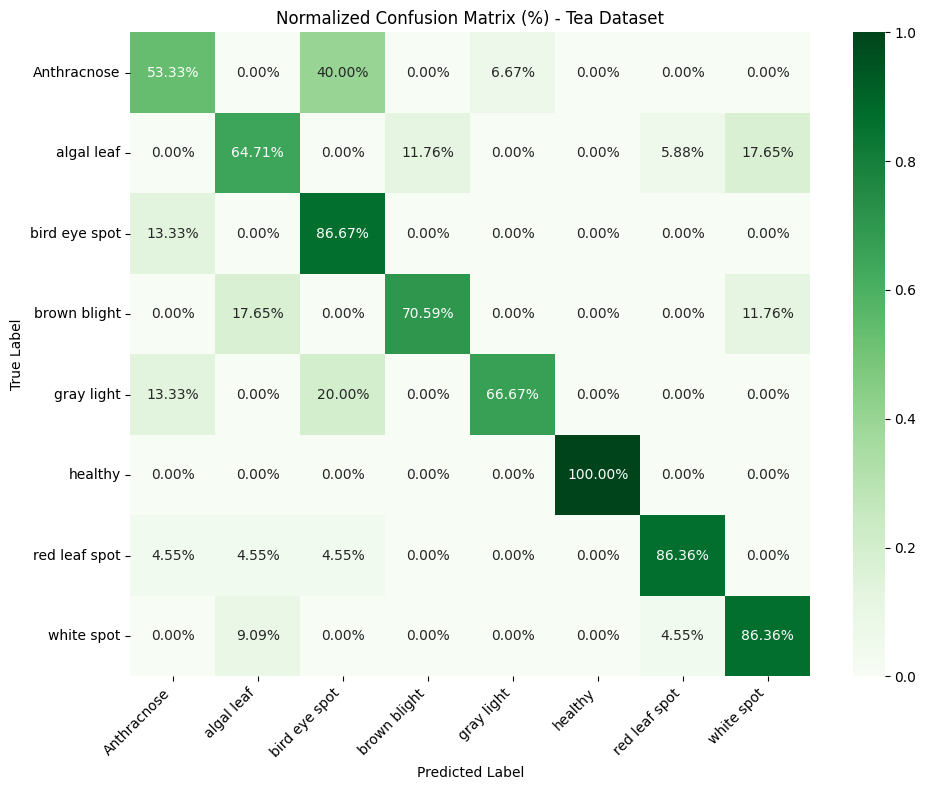

In [18]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (%) - Tea Dataset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/tea_confusion_matrix_normalized.png', dpi=150)
plt.show()

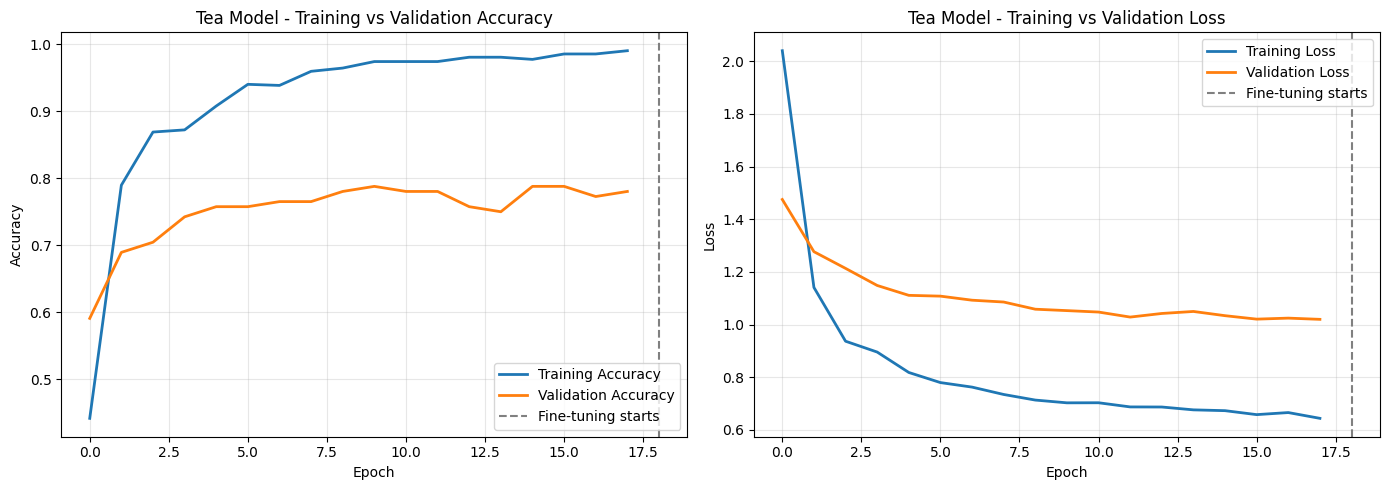

In [20]:
def combine_histories(*histories):
    combined = {}
    for h in histories:
        for key, values in h.history.items():
            combined.setdefault(key, []).extend(values)
    return combined

all_history = combine_histories(history1)

acc = all_history['accuracy']
val_acc = all_history['val_accuracy']
loss = all_history['loss']
val_loss = all_history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.axvline(x=len(history1.history['accuracy']), color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend(loc='lower right')
plt.title('Tea Model - Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=len(history1.history['loss']), color='gray', linestyle='--', label='Fine-tuning starts')
plt.legend(loc='upper right')
plt.title('Tea Model - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/tea_training_curves.png', dpi=150)
plt.show()

In [21]:
model.save('/content/drive/MyDrive/tea_model_final.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('/content/tea_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Tea TFLite model saved, size:", len(tflite_model) / (1024*1024), "MB")

Saved artifact at '/tmp/tmpamilkcgq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_159')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  132206671688912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671690256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671690448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671689680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671688720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671690640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671691600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671687952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671691408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132206671691024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322066706

In [22]:
import json
from google.colab import files

class_indices = {i: name for i, name in enumerate(class_names)}
with open('/content/tea_class_labels.json', 'w') as f:
    json.dump(class_indices, f, indent=2)

files.download('/content/tea_model.tflite')
files.download('/content/tea_class_labels.json')
files.download('/content/tea_confusion_matrix.png')
files.download('/content/tea_training_curves.png')
files.download('/content/tea_classification_report.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving IMG_20220503_135418.jpg to IMG_20220503_135418.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


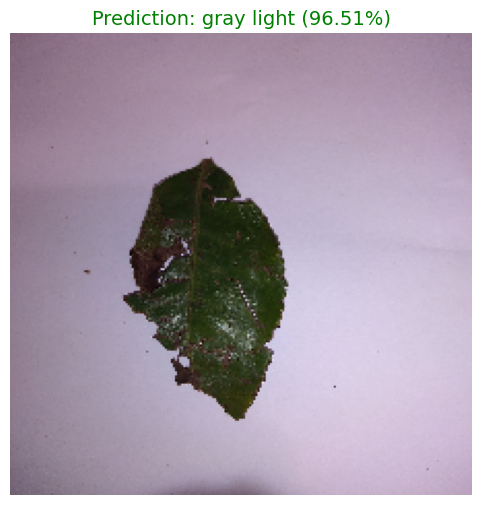

In [23]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
img_array = tf.keras.utils.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

predictions = model.predict(img_preprocessed)
predicted_index = np.argmax(predictions[0])
confidence = predictions[0][predicted_index] * 100
predicted_class = class_names[predicted_index]

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)", fontsize=14,
          color='green' if confidence > 80 else 'orange')
plt.show()